<a href="https://colab.research.google.com/github/UKD1211/Tier_N_Supplier_Visibility_Risk_Pred/blob/main/real_supplier_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
df_final = pd.read_excel("/content/output.xlsx")

In [3]:
df_final

,State,avg_unemployment_rate,per_capita_income,inflation_rate,poverty_rate,state_risk_cal
0,Andaman & Nicobar Islands,9.766667,256518.000000,5.480946,0.01,0.400079
1,Andhra Pradesh,4.133333,217190.333333,5.989730,0.03,0.633688
2,Arunachal Pradesh,6.200000,204215.000000,5.480946,0.06,0.614160
3,Assam,3.133333,122932.000000,5.580270,0.09,0.806901
4,Bihar,4.300000,54711.333333,6.024054,0.16,1.000000
5,Chandigarh,5.800000,399791.666667,4.957297,0.02,0.364666
6,Chhattisgarh,2.500000,135803.666667,4.777297,0.07,0.709485
7,Dadra and Nagar Haveli and Daman and Diu,3.333333,223005.196970,5.480946,0.03,0.607092
8,Delhi,3.100000,415816.333333,3.298108,0.01,0.262736
9,Goa,10.066667,525967.000000,3.192162,0.00,0.000000


In [4]:
industries = {
    "Textiles": 0.8,
    "Mining": 0.9,
    "Electronics": 0.4,
    "Agriculture": 0.7,
    "Pharma": 0.3
}

In [5]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 488

tiers = np.random.choice([1,2,3,4], size=n, p=[0.25,0.30,0.25,0.20])
states = np.random.choice(df_final["State"], size=n)

df_suppliers = pd.DataFrame({
    "supplier_id": [f"S{i:03d}" for i in range(n)],
    "tier": tiers,
    "state": states
})

In [6]:
df_suppliers["industry"] = np.random.choice(
    list(industries.keys()),
    size=n,
    p=[0.25, 0.20, 0.20, 0.20, 0.15]
)

In [7]:
df_suppliers = df_suppliers.merge(
    df_final[["State", "state_risk_cal"]],
    left_on="state",
    right_on="State",
    how="left"
).drop(columns=["State"])

In [8]:
df_suppliers["visibility_score"] = 1 / df_suppliers["tier"] + np.random.normal(0, 0.05, n)

In [9]:
df_suppliers["audit_score"] = (
    1 - df_suppliers["state_risk_cal"] * 0.6
    - df_suppliers["tier"] * 0.05
    + np.random.normal(0, 0.05, n)
).clip(0,1)

In [10]:
df_suppliers["cost_pressure"] = (
    df_suppliers["state_risk_cal"] * 0.5 +
    df_suppliers["tier"] * 0.1 +
    np.random.normal(0, 0.05, n)
)

In [11]:
df_suppliers["delivery_delay"] = (
    df_suppliers["tier"] * 2 +
    df_suppliers["state_risk_cal"] * 5 +
    np.random.normal(0, 1, n)
)

In [12]:
df_suppliers["industry_risk"] = df_suppliers["industry"].map(industries)

In [13]:
df_suppliers["risk_score"] = (
    0.35 * df_suppliers["state_risk_cal"] +
    0.20 * df_suppliers["industry_risk"] +
    0.15 * df_suppliers["cost_pressure"] +
    0.15 * (1 - df_suppliers["audit_score"]) +
    0.15 * (1 - df_suppliers["visibility_score"])
)

In [14]:
df_suppliers["compliance_flag"] = (df_suppliers["risk_score"] > 0.6).astype(int)

In [15]:
df_suppliers

,supplier_id,tier,state,industry,state_risk_cal,visibility_score,audit_score,cost_pressure,delivery_delay,industry_risk,risk_score,compliance_flag
0,S000,2,Telangana,Mining,0.585616,0.418164,0.602187,0.484383,7.458270,0.9,0.604570,1
1,S001,4,Karnataka,Pharma,0.560137,0.310285,0.427510,0.690043,8.842243,0.3,0.548885,0
2,S002,3,Dadra and Nagar Haveli and Daman and Diu,Textiles,0.607092,0.408068,0.478203,0.570632,8.676612,0.8,0.625136,1
3,S003,3,Haryana,Pharma,0.586830,0.342221,0.486052,0.573727,8.990778,0.3,0.527209,0
4,S004,1,Mizoram,Agriculture,0.594921,0.976614,0.610612,0.417346,5.107756,0.7,0.472740,0
...,...,...,...,...,...,...,...,...,...,...,...,...
483,S483,3,Meghalaya,Electronics,0.722640,0.324871,0.421960,0.679648,11.148764,0.4,0.622847,1
484,S484,3,Haryana,Pharma,0.586830,0.339787,0.520978,0.551069,9.472879,0.3,0.518936,0
485,S485,4,Madhya Pradesh,Mining,0.854513,0.225551,0.332466,0.913249,12.061292,0.9,0.832365,1
486,S486,1,Bihar,Mining,1.000000,0.902606,0.329277,0.562134,6.560037,0.9,0.729538,1


In [16]:
df_suppliers['industry'].value_counts()

,count
industry,
Textiles,117
Electronics,110
Agriculture,97
Mining,89
Pharma,75


In [17]:
df_suppliers['state'].value_counts()

,count
state,
Odisha,22
Tripura,19
Bihar,19
Dadra and Nagar Haveli and Daman and Diu,18
Sikkim,17
Andaman & Nicobar Islands,17
Punjab,17
Chandigarh,16
Jammu and Kashmir,16


In [18]:
df_final

,State,avg_unemployment_rate,per_capita_income,inflation_rate,poverty_rate,state_risk_cal
0,Andaman & Nicobar Islands,9.766667,256518.000000,5.480946,0.01,0.400079
1,Andhra Pradesh,4.133333,217190.333333,5.989730,0.03,0.633688
2,Arunachal Pradesh,6.200000,204215.000000,5.480946,0.06,0.614160
3,Assam,3.133333,122932.000000,5.580270,0.09,0.806901
4,Bihar,4.300000,54711.333333,6.024054,0.16,1.000000
5,Chandigarh,5.800000,399791.666667,4.957297,0.02,0.364666
6,Chhattisgarh,2.500000,135803.666667,4.777297,0.07,0.709485
7,Dadra and Nagar Haveli and Daman and Diu,3.333333,223005.196970,5.480946,0.03,0.607092
8,Delhi,3.100000,415816.333333,3.298108,0.01,0.262736
9,Goa,10.066667,525967.000000,3.192162,0.00,0.000000


In [19]:
pd.read_csv("/content/India_SDG_Index_State_Rank_Data_2023-24.csv")

,Composite,Unnamed: 1,Unnamed: 2
0,NaN,NaN,NaN
1,AREA,2023-24,2020.0
2,India,71,66.0
3,Kerala,79,75.0
4,Uttarakhand,79,72.0
5,Tamil Nadu,78,74.0
6,Goa,77,72.0
7,Himachal Pradesh,77,74.0
8,Punjab,76,68.0
9,Sikkim,76,71.0


In [20]:
df_sdg = pd.read_csv("/content/India_SDG_Index_State_Rank_Data_2023-24.csv", header=1)

In [21]:
df_sdg.columns = ["State", "SDG_2023_24", "SDG_2020"]

In [22]:
df_sdg = df_sdg[df_sdg["State"] != "India"]

In [23]:
df_sdg.iloc[1:,:].drop(columns = ['SDG_2020']).sort_values(by = 'State').reset_index(drop = True)

,State,SDG_2023_24
0,Andhra Pradesh,74
1,Arunachal Pradesh,65
2,Assam,65
3,Bihar,57
4,Chhattisgarh,67
5,Goa,77
6,Gujarat,74
7,Haryana,72
8,Himachal Pradesh,77
9,Jharkhand,62


In [24]:
df_sdg_24 = df_sdg.iloc[1:,:].drop(columns = ['SDG_2020']).sort_values(by = 'State').reset_index(drop = True)

In [25]:
df_final = df_final.merge(df_sdg_24, left_on = 'State', right_on = 'State')

In [26]:
df_final.sort_values(by = 'SDG_2023_24')

,State,avg_unemployment_rate,per_capita_income,inflation_rate,poverty_rate,state_risk_cal,SDG_2023_24
3,Bihar,4.300000,54711.333333,6.024054,0.16,1.000000,57
9,Jharkhand,1.666667,96956.000000,5.514324,0.13,0.930478,62
17,Nagaland,6.833333,140314.000000,4.514324,0.07,0.588101,63
15,Meghalaya,4.933333,124613.000000,4.069189,0.13,0.722640,63
1,Arunachal Pradesh,6.200000,204215.000000,5.480946,0.06,0.614160,65
2,Assam,3.133333,122932.000000,5.580270,0.09,0.806901,65
18,Odisha,4.333333,139598.000000,6.275405,0.07,0.784600,66
4,Chhattisgarh,2.500000,135803.666667,4.777297,0.07,0.709485,67
25,Uttar Pradesh,2.766667,86022.333333,6.295405,0.10,0.917599,67
20,Rajasthan,4.433333,150270.000000,6.096486,0.07,0.760532,67


np.float64(-0.7264560429577468)

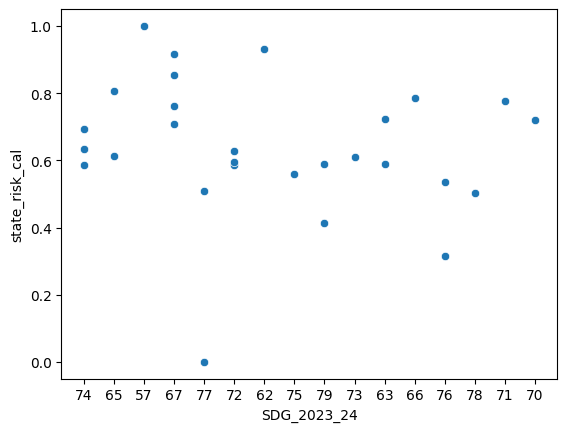

In [27]:
import seaborn as sns
sns.scatterplot(data = df_final, y = 'state_risk_cal', x = 'SDG_2023_24')
df_final['state_risk_cal'].corr(df_final['SDG_2023_24'])

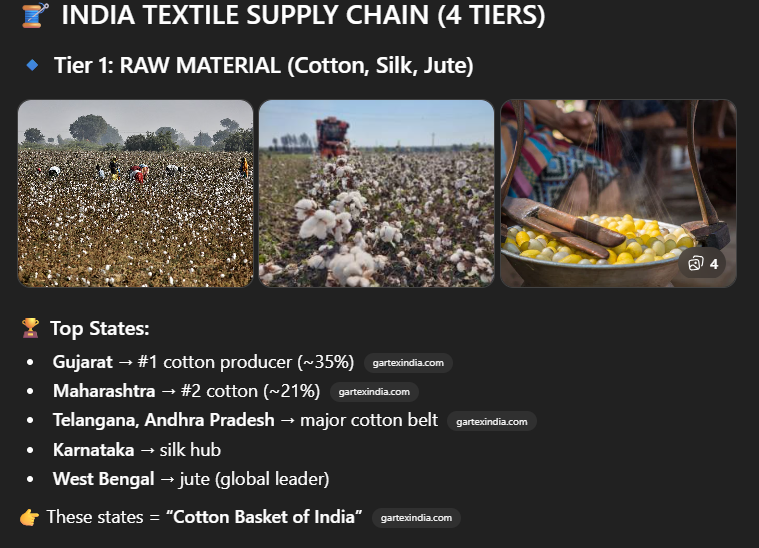

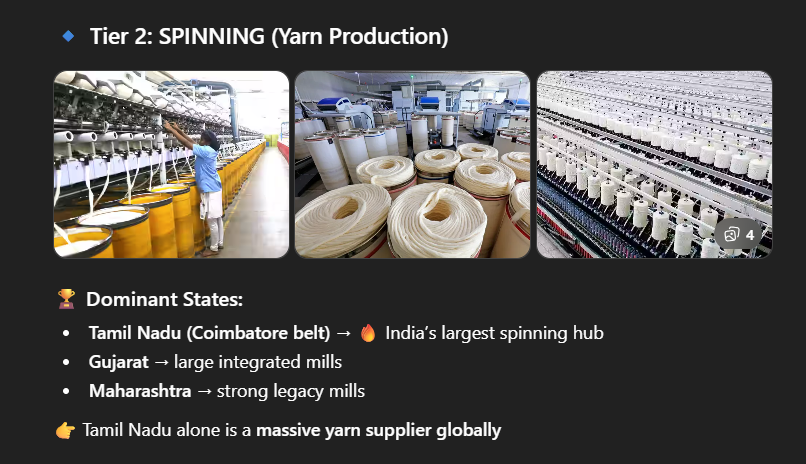

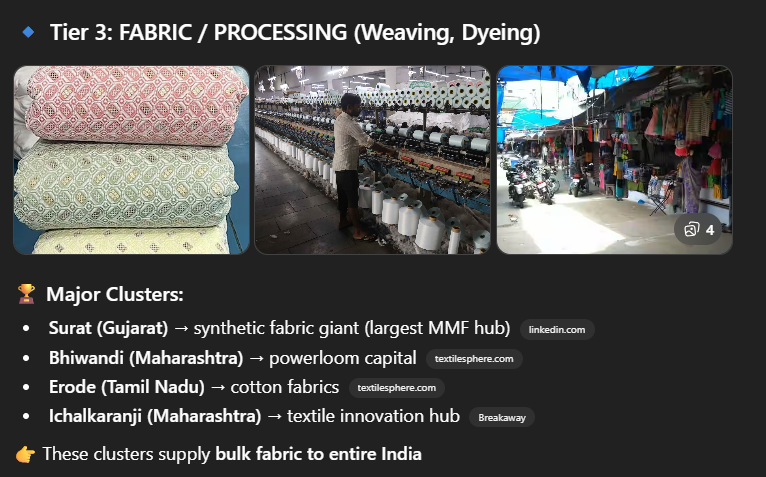

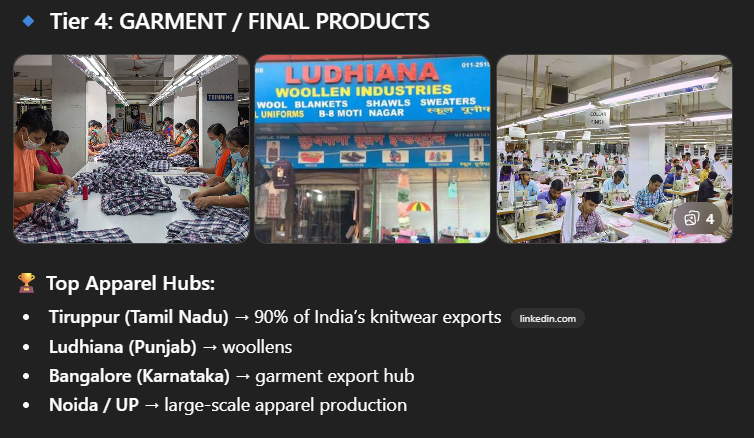

In [28]:
tier1 = [
    ("Gujarat","Cotton Belt"),
    ("Maharashtra","Vidarbha"),
    ("Telangana","Cotton Belt"),
    ("Andhra Pradesh","Cotton Belt"),
    ("Karnataka","Mysore Silk"),
    ("West Bengal","Hooghly Jute")
]

tier2 = [
    ("Tamil Nadu","Coimbatore"),
    ("Gujarat","Ahmedabad"),
    ("Maharashtra","Mumbai")
]

tier3 = [
    ("Gujarat","Surat"),
    ("Maharashtra","Bhiwandi"),
    ("Tamil Nadu","Erode"),
    ("Maharashtra","Ichalkaranji")
]

tier4 = [
    ("Tamil Nadu","Tiruppur"),
    ("Punjab","Ludhiana"),
    ("Karnataka","Bangalore"),
    ("Uttar Pradesh","Noida")
]

In [29]:
import numpy as np
import pandas as pd

np.random.seed(42)

rows = []

def generate_suppliers(tier_data, tier_num, n):
    for i in range(n):
        state, cluster = tier_data[np.random.randint(len(tier_data))]

        rows.append({
            "supplier_id": f"T{tier_num}_{i:03d}",
            "tier": tier_num,
            "state": state,
            "cluster": cluster
        })

# realistic distribution
generate_suppliers(tier1, 1, 30)
generate_suppliers(tier2, 2, 30)
generate_suppliers(tier3, 3, 30)
generate_suppliers(tier4, 4, 30)

df_textile = pd.DataFrame(rows)

In [30]:
stage_map = {1:"Raw", 2:"Spinning", 3:"Fabric", 4:"Garment"}
df_textile["stage"] = df_textile["tier"].map(stage_map)

In [31]:
df_textile = df_textile.merge(
    df_final[["State","state_risk_cal","SDG_2023_24"]],
    left_on="state",
    right_on="State",
    how="left"
).drop(columns=["State"])

In [32]:
labour_map = {
    "Raw": 0.6,
    "Spinning": 0.5,
    "Fabric": 0.8,
    "Garment": 0.95
}

df_textile["labour_intensity"] = df_textile["stage"].map(labour_map)

In [33]:
informal_map = {
    "Surat": 0.85,
    "Bhiwandi": 0.90,
    "Tiruppur": 0.65,
    "Coimbatore": 0.45,
    "Erode": 0.60,
    "Ichalkaranji": 0.70,
    "Noida": 0.75,
    "Ludhiana": 0.60
}

df_textile["informality"] = df_textile["cluster"].map(informal_map).fillna(0.55)

In [34]:
df_textile["visibility"] = 1 / df_textile["tier"] + np.random.normal(0, 0.05, len(df_textile))

In [35]:
df_textile["audit_score"] = (
    1
    - df_textile["state_risk_cal"]*0.5
    - df_textile["informality"]*0.3
    + np.random.normal(0, 0.05, len(df_textile))
).clip(0,1)

In [36]:
df_textile["cost_pressure"] = (
    df_textile["tier"]*0.1 +
    df_textile["state_risk_cal"]*0.4 +
    df_textile["informality"]*0.3 +
    np.random.normal(0, 0.05, len(df_textile))
)

In [37]:
df_textile["delivery_delay"] = (
    df_textile["tier"]*2 +
    df_textile["informality"]*3 +
    df_textile["state_risk_cal"]*4 +
    np.random.normal(0, 1, len(df_textile))
)

In [38]:
df_textile["risk_score"] = (
    0.30 * df_textile["state_risk_cal"] +
    0.20 * df_textile["informality"] +
    0.15 * df_textile["labour_intensity"] +
    0.15 * df_textile["cost_pressure"] -
    0.10 * df_textile["audit_score"] -
    0.05 * df_textile["visibility"] -
    0.05 * (pd.to_numeric(df_textile["SDG_2023_24"], errors='coerce') / 100)
)

In [39]:
df_textile["high_risk"] = (df_textile["risk_score"] > 0.6).astype(int)

In [40]:
df_textile.high_risk.value_counts()

,count
high_risk,
0,111
1,9


In [41]:
df_textile.iloc[:,0:7]

,supplier_id,tier,state,cluster,stage,state_risk_cal,SDG_2023_24
0,T1_000,1,Andhra Pradesh,Cotton Belt,Raw,0.633688,74
1,T1_001,1,Karnataka,Mysore Silk,Raw,0.560137,75
2,T1_002,1,Telangana,Cotton Belt,Raw,0.585616,74
3,T1_003,1,Karnataka,Mysore Silk,Raw,0.560137,75
4,T1_004,1,Karnataka,Mysore Silk,Raw,0.560137,75
...,...,...,...,...,...,...,...
115,T4_025,4,Karnataka,Bangalore,Garment,0.560137,75
116,T4_026,4,Tamil Nadu,Tiruppur,Garment,0.501682,78
117,T4_027,4,Uttar Pradesh,Noida,Garment,0.917599,67
118,T4_028,4,Tamil Nadu,Tiruppur,Garment,0.501682,78


In [42]:
df_textile

,supplier_id,tier,state,cluster,stage,state_risk_cal,SDG_2023_24,labour_intensity,informality,visibility,audit_score,cost_pressure,delivery_delay,risk_score,high_risk
0,T1_000,1,Andhra Pradesh,Cotton Belt,Raw,0.633688,74,0.60,0.55,1.031815,0.585314,0.579986,7.338284,0.329982,0
1,T1_001,1,Karnataka,Mysore Silk,Raw,0.560137,75,0.60,0.55,0.954664,0.518204,0.424494,5.515537,0.294662,0
2,T1_002,1,Telangana,Cotton Belt,Raw,0.585616,74,0.60,0.55,1.023802,0.494197,0.576992,5.298317,0.324624,0
3,T1_003,1,Karnataka,Mysore Silk,Raw,0.560137,75,0.60,0.55,1.065183,0.610178,0.439995,6.000408,0.282263,0
4,T1_004,1,Karnataka,Mysore Silk,Raw,0.560137,75,0.60,0.55,1.010579,0.586644,0.427143,6.233005,0.285419,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,T4_025,4,Karnataka,Bangalore,Garment,0.560137,75,0.95,0.55,0.153271,0.511527,0.766683,10.252554,0.439227,0
116,T4_026,4,Tamil Nadu,Tiruppur,Garment,0.501682,78,0.95,0.65,0.257533,0.526907,0.812703,12.453305,0.440343,0
117,T4_027,4,Uttar Pradesh,Noida,Garment,0.917599,67,0.95,0.75,0.249214,0.252831,0.991351,13.726145,0.645239,1
118,T4_028,4,Tamil Nadu,Tiruppur,Garment,0.501682,78,0.95,0.65,0.183496,0.559674,0.864292,11.750488,0.448506,0


In [43]:
df_textile.state.value_counts()

,count
state,
Maharashtra,39
Tamil Nadu,26
Gujarat,15
Karnataka,11
Uttar Pradesh,9
Andhra Pradesh,6
Telangana,6
West Bengal,4
Punjab,4


In [46]:
df_textile.to_excel("df_textile.xlsx")